#RESUMO EXECUTIVO

##Objetivo

Analisar o catálogo da Netflix para identificar padrões de produção, distribuição e composição do conteúdo disponível.

##Principais Descobertas

- O catálogo é composto majoritariamente por filmes.
- Os Estados Unidos lideram a produção de títulos.
- Há crescimento significativo das séries nos últimos anos.
- Dramas e conteúdos internacionais são os gêneros mais frequentes.
- A maior parte dos filmes possui duração entre 80 e 120 minutos.
- Existem poucos filmes com duração extremamente elevada, caracterizando outliers.
- O catálogo apresenta forte concentração em alguns países e gêneros.

##Insight 15

A distribuição das classificações indicativas varia entre filmes e séries, indicando diferenças no público-alvo de cada tipo de conteúdo.

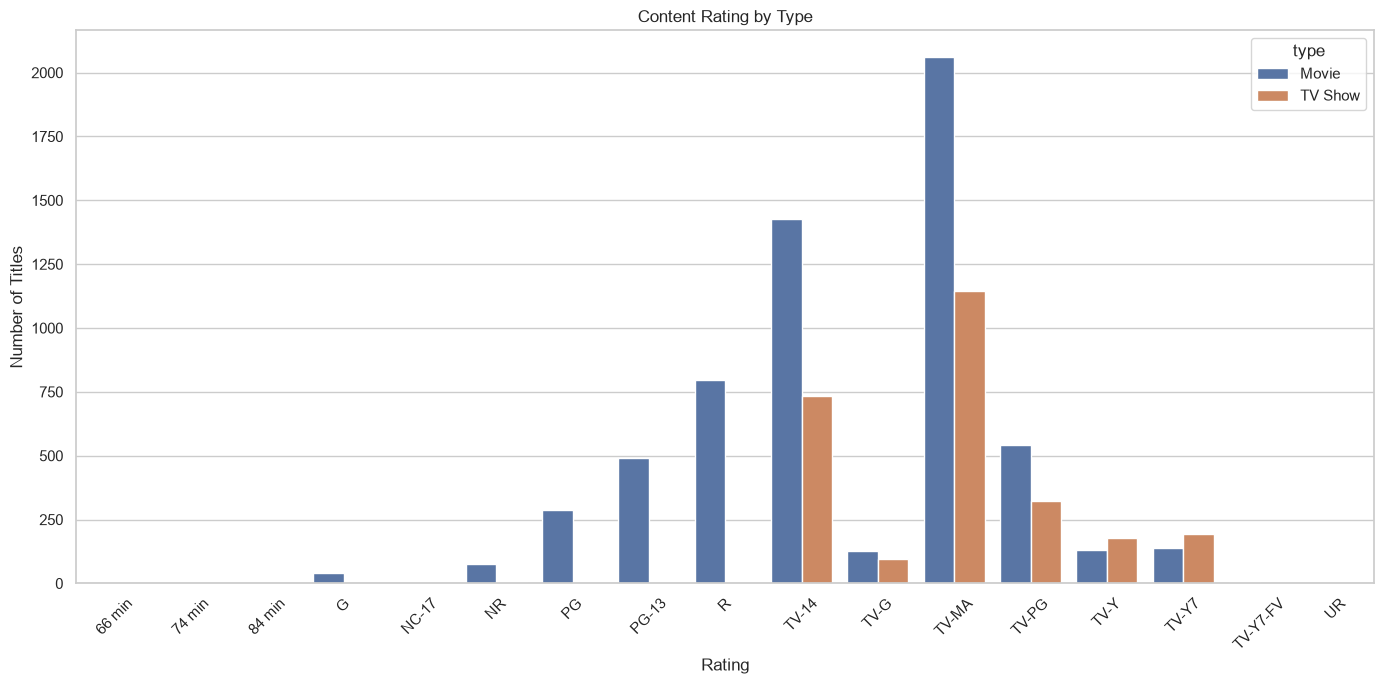

In [5]:
#Questão 15 - Código
rating_table = (
    df
    .groupby(["rating", "type"])
    .size()
    .reset_index(name="count")
)

rating_table.head()

#Gráfico
plt.figure(figsize=(14, 7))

sns.barplot(
    data=rating_table,
    x="rating",
    y="count",
    hue="type"
)

plt.xticks(rotation=45)

plt.title("Content Rating by Type")

plt.xlabel("Rating")

plt.ylabel("Number of Titles")

plt.tight_layout()

plt.savefig(
    "../images/rating_by_type.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

##Questão 16
- Como as classificações indicativas se distribuem entre filmes e séries?

##Insight 15

Alguns gêneros são claramente dominados por filmes, enquanto outros apresentam forte presença de séries.
Essas diferenças podem refletir a estratégia de produção e aquisição da plataforma.

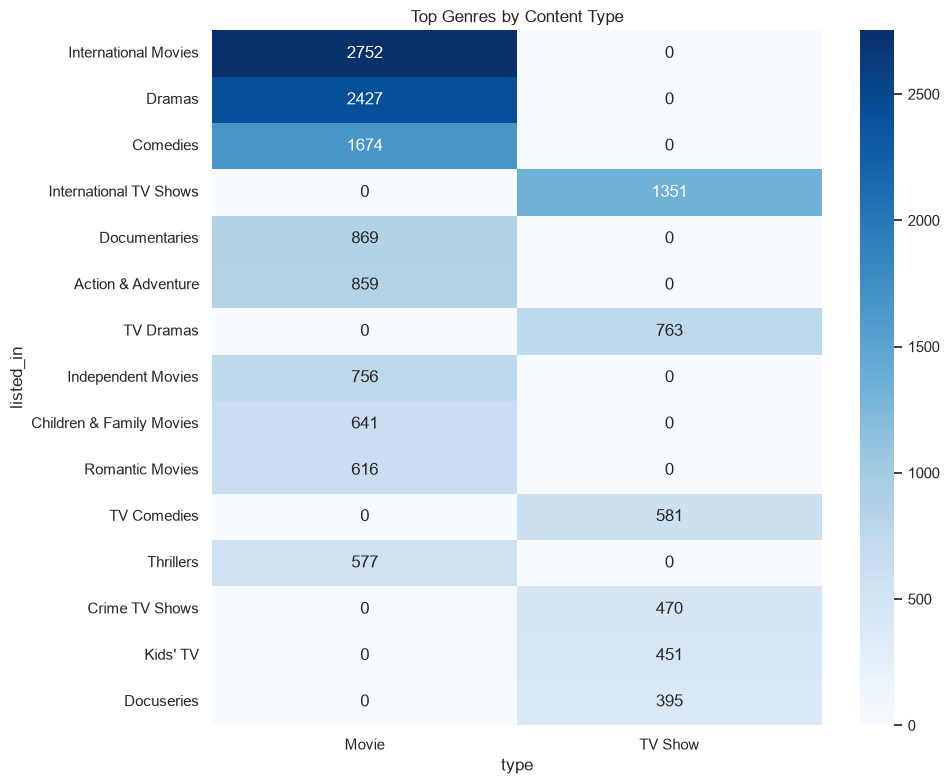

In [4]:
##Questão 15 - Código
#Preparar seleção
genre_df = (
    df[["type", "listed_in"]]
    .copy()
)

genre_df["listed_in"] = (
    genre_df["listed_in"]
    .str.split(", ")
)

genre_df = genre_df.explode("listed_in")

#Tabela dinâmica
genre_table = (
    genre_df
    .pivot_table(
        index="listed_in",
        columns="type",
        aggfunc="size",
        fill_value=0
    )
)

genre_table.head()

#Top 15 gêneros
top_genres = (
    genre_table
    .sum(axis=1)
    .sort_values(ascending=False)
    .head(15)
    .index
)

genre_table.loc[top_genres]

#Heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    genre_table.loc[top_genres],
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Top Genres by Content Type")

plt.tight_layout()

plt.savefig(
    "../images/genre_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#Questão 15
- Quais gêneros predominam em filmes e em séries?

##Insight 14

Poucos atores aparecem repetidamente no catálogo.
Isso evidencia parcerias frequentes da plataforma com determinados artistas e produtoras.

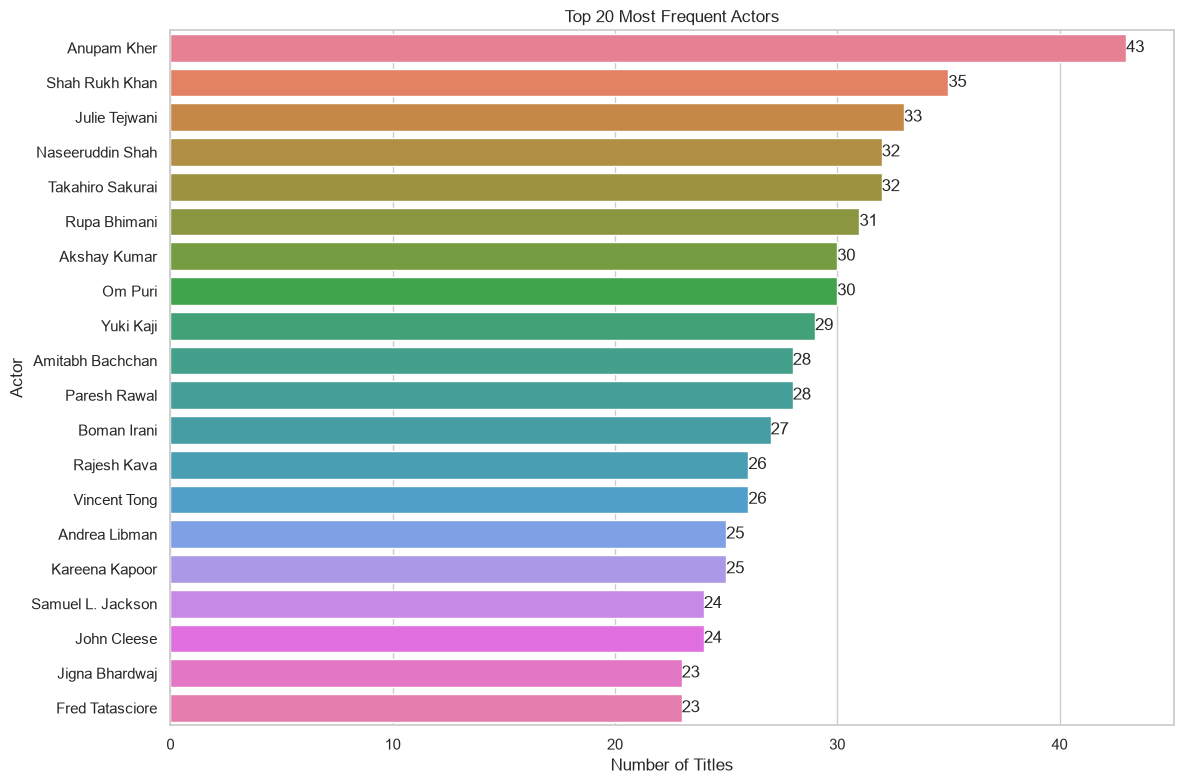

In [3]:
##Questão14 - Código
#Preparar seleção

cast_df = (
    df[["title", "cast"]]
    .dropna(subset=["cast"])
    .copy()
)

#Separando elenco
cast_df["cast"] = (
    cast_df["cast"]
    .str.split(", ")
)

cast_df = cast_df.explode("cast")

cast_df.head()

#Contagem
top_cast = (
    cast_df["cast"]
    .value_counts()
    .head(20)
)

top_cast

#Gráfico
plt.figure(figsize=(12, 8))

ax = sns.barplot(
    x=top_cast.values,
    y=top_cast.index,
    hue=top_cast.index,
    legend=False
)

plt.title("Top 20 Most Frequent Actors")

plt.xlabel("Number of Titles")

plt.ylabel("Actor")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()

plt.savefig(
    "../images/top_actors.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


#Questão 14
- Quais atores aparecem com maior frequência?

In [2]:
#Carregar dataset
DATASET_PATH = "../data/processed/netflix_clean.csv"

df = pd.read_csv(
    DATASET_PATH,
    parse_dates=["date_added"]
)

In [1]:
#Confiurar ambiente

import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (12, 6)

pd.set_option("display.max_columns", 100)

#7 — Storytelling e Insights Finais

Este notebook reúne análises complementares e consolida os principais resultados do estudo.
- Novas análises;
- Principais insights;
- Material para o README do GitHub.